In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats 
import pyodbc

In [2]:
print(pyodbc.drivers())

['SQL Server', 'ODBC Driver 17 for SQL Server', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)', 'SQL Server Native Client RDA 11.0', 'ODBC Driver 18 for SQL Server', 'MySQL ODBC 8.3 ANSI Driver', 'MySQL ODBC 8.3 Unicode Driver', 'PostgreSQL ANSI(x64)', 'PostgreSQL Unicode(x64)', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)']


In [3]:
connection = pyodbc.connect(driver = "{ODBC Driver 17 for SQL Server}",server = 'DESKTOP-CB8O1S6' , database = 'Medical_db',trusted_connection='Yes')

In [4]:
pd.read_sql_query('Select * from [dataset_]',con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_17200\2882539660.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query('Select * from [dataset_]',con=connection)


,age,sex,bmi,children,smoker,region,medical_charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# Data in Dataframe then bit of EDA and Cleaning using Python then Analysis using SQL

In [5]:
df = pd.read_sql_query('Select * from [dataset_]',con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_17200\3516071775.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query('Select * from [dataset_]',con=connection)


In [6]:
df.head()

,age,sex,bmi,children,smoker,region,medical_charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.shape

(1338, 7)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              1338 non-null   int64  
 1   sex              1338 non-null   object 
 2   bmi              1338 non-null   float64
 3   children         1338 non-null   int64  
 4   smoker           1338 non-null   object 
 5   region           1338 non-null   object 
 6   medical_charges  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# Changed Datatype of Children Need to change in Database As Well

In [9]:
df['children'] = pd.to_numeric(df['children'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              1338 non-null   int64  
 1   sex              1338 non-null   object 
 2   bmi              1338 non-null   float64
 3   children         1338 non-null   int64  
 4   smoker           1338 non-null   object 
 5   region           1338 non-null   object 
 6   medical_charges  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [11]:
with connection.cursor() as cursor:
    cursor.execute('Alter Table [dataset_] Alter Column children INT')

In [12]:
df.head()

,age,sex,bmi,children,smoker,region,medical_charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


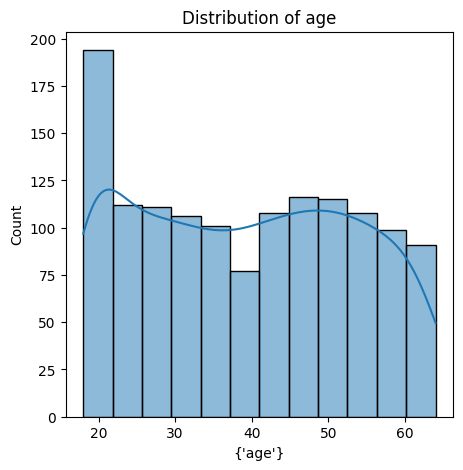

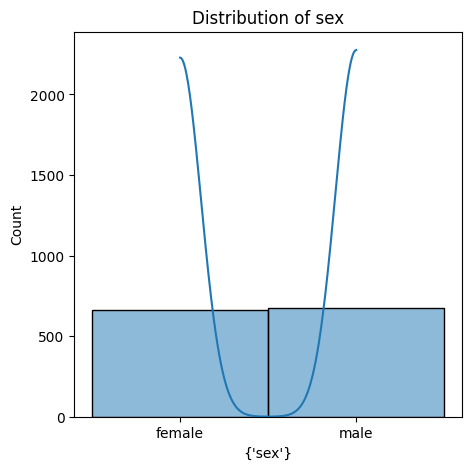

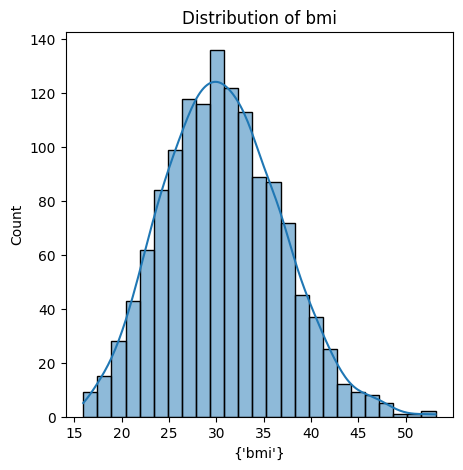

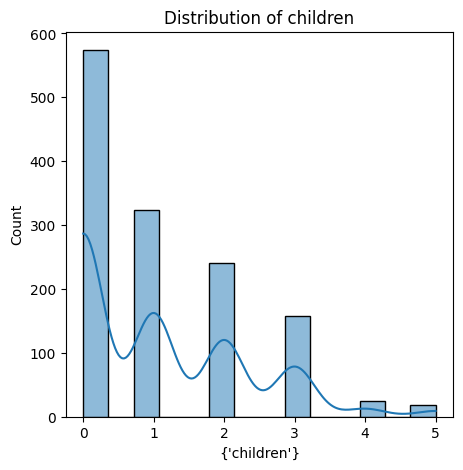

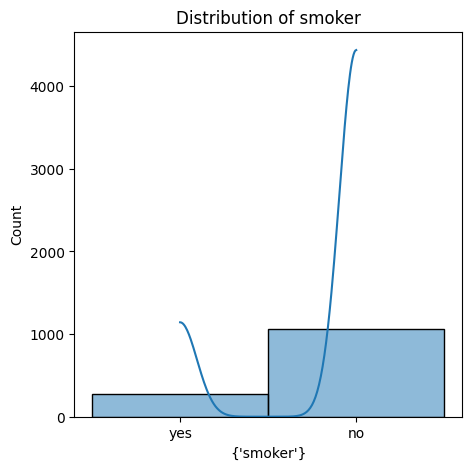

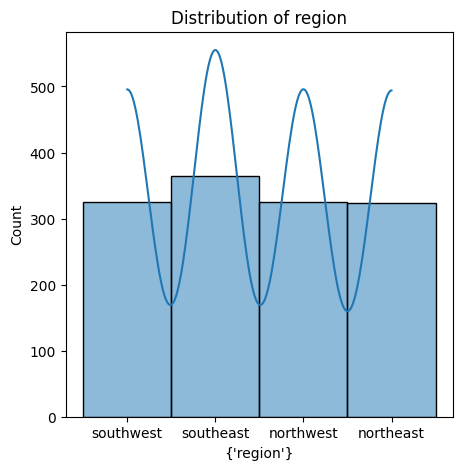

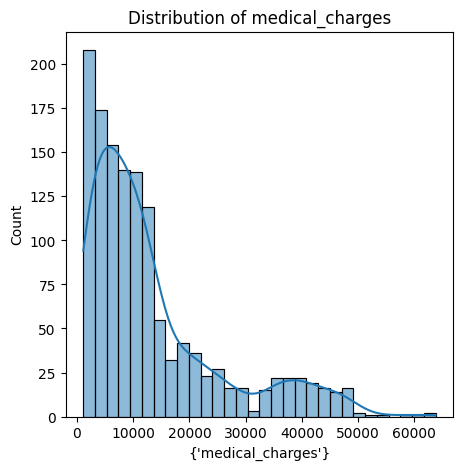

In [13]:
for i in df.columns:
    plt.figure(figsize=(5,5))
    sns.histplot(data=df,x=i, kde=True )
    plt.title(f'Distribution of {i}')
    plt.xlabel({i})
    plt.show()


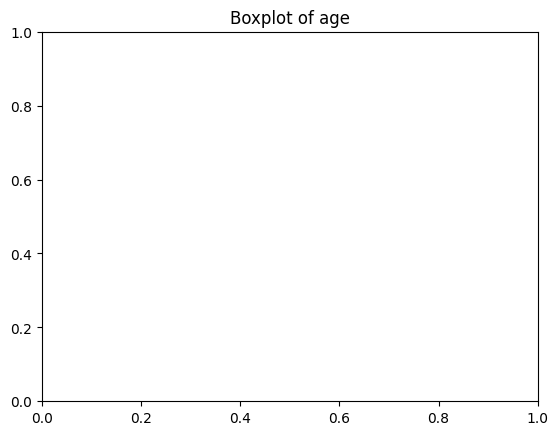

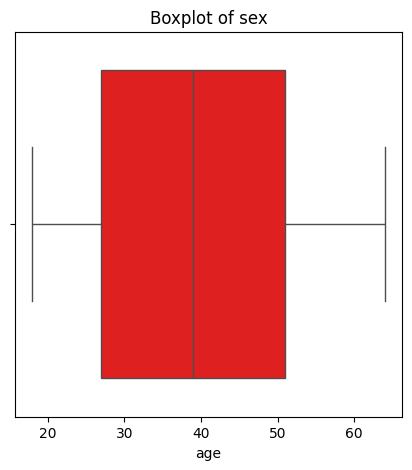

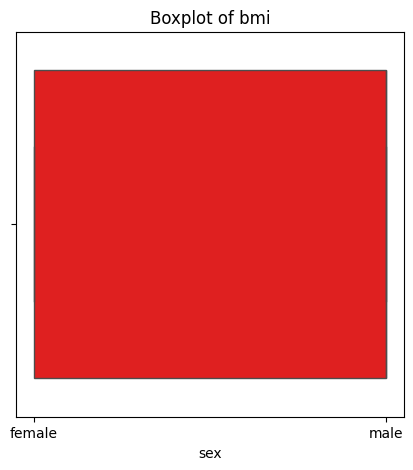

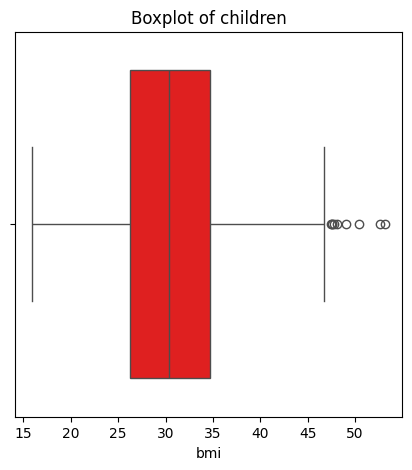

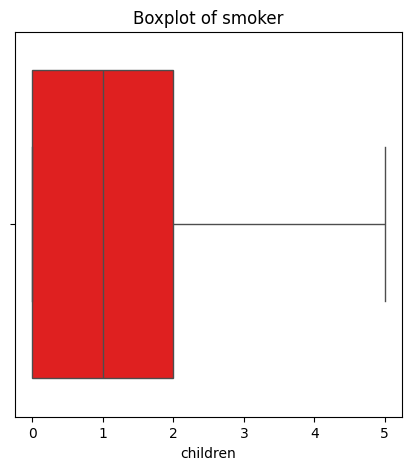

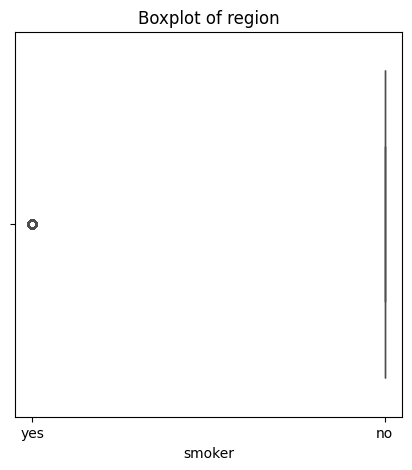

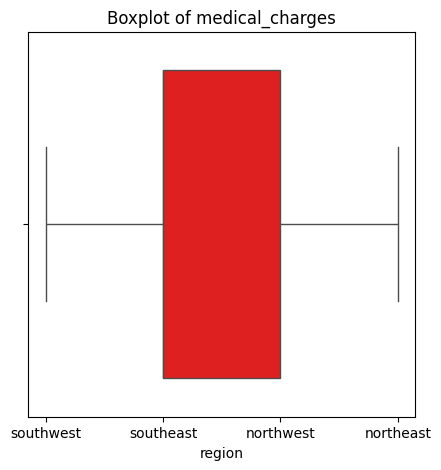

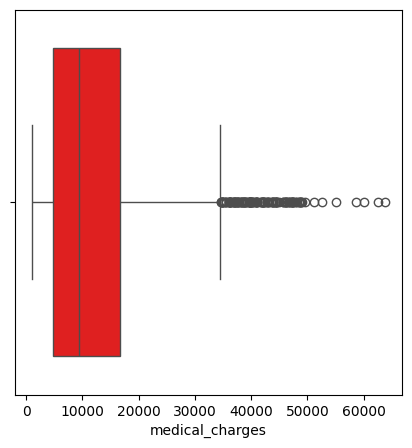

In [14]:
for i in df.columns:
    plt.title(f'Boxplot of {i}')
    plt.figure(figsize=(5,5))
    plt.xlabel(i)
    sns.boxplot(data=df,x=i,color='Red')
    



<Axes: >

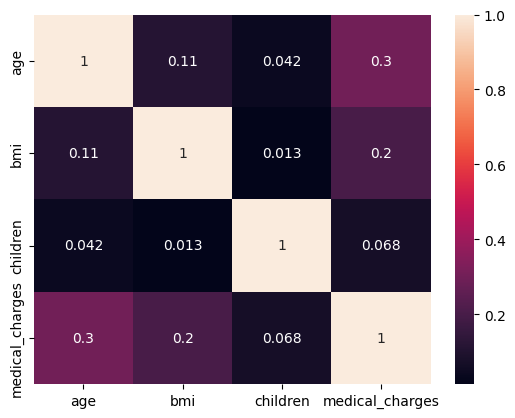

In [15]:
Correlation = df.corr(numeric_only=True)
sns.heatmap(Correlation,annot=True)

In [16]:
df.head()

,age,sex,bmi,children,smoker,region,medical_charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [17]:
df['age'].unique()

array([19, 18, 28, 33, 32, 31, 46, 37, 60, 25, 62, 23, 56, 27, 52, 30, 34,
       59, 63, 55, 22, 26, 35, 24, 41, 38, 36, 21, 48, 40, 58, 53, 43, 64,
       20, 61, 44, 57, 29, 45, 54, 49, 47, 51, 42, 50, 39])

In [18]:
df['bmi'].unique()

array([27.9  , 33.77 , 33.   , 22.705, 28.88 , 25.74 , 33.44 , 27.74 ,
       29.83 , 25.84 , 26.22 , 26.29 , 34.4  , 39.82 , 42.13 , 24.6  ,
       30.78 , 23.845, 40.3  , 35.3  , 36.005, 32.4  , 34.1  , 31.92 ,
       28.025, 27.72 , 23.085, 32.775, 17.385, 36.3  , 35.6  , 26.315,
       28.6  , 28.31 , 36.4  , 20.425, 32.965, 20.8  , 36.67 , 39.9  ,
       26.6  , 36.63 , 21.78 , 30.8  , 37.05 , 37.3  , 38.665, 34.77 ,
       24.53 , 35.2  , 35.625, 33.63 , 28.   , 34.43 , 28.69 , 36.955,
       31.825, 31.68 , 22.88 , 37.335, 27.36 , 33.66 , 24.7  , 25.935,
       22.42 , 28.9  , 39.1  , 36.19 , 23.98 , 24.75 , 28.5  , 28.1  ,
       32.01 , 27.4  , 34.01 , 29.59 , 35.53 , 39.805, 26.885, 38.285,
       37.62 , 41.23 , 34.8  , 22.895, 31.16 , 27.2  , 26.98 , 39.49 ,
       24.795, 31.3  , 38.28 , 19.95 , 19.3  , 31.6  , 25.46 , 30.115,
       29.92 , 27.5  , 28.4  , 30.875, 27.94 , 35.09 , 29.7  , 35.72 ,
       32.205, 28.595, 49.06 , 27.17 , 23.37 , 37.1  , 23.75 , 28.975,
      

In [19]:
df['children'].unique()

array([0, 1, 3, 2, 5, 4])

In [20]:
df['medical_charges'].unique()

array([16884.924 ,  1725.5523,  4449.462 , ...,  1629.8335,  2007.945 ,
       29141.3603])

In [21]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [22]:
df['sex'].unique()

array(['female', 'male'], dtype=object)

In [23]:
df['smoker'].unique()

array(['yes', 'no'], dtype=object)

In [24]:
df['age'].min()

np.int64(18)

In [25]:
df['age'].max()

np.int64(64)

# Analysis Using SQL and Python Visualizations

In [26]:
pd.read_sql_query('Select * from [dataset_]',con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_17200\2882539660.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query('Select * from [dataset_]',con=connection)


,age,sex,bmi,children,smoker,region,medical_charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# KPI's

In [27]:
df.head()

,age,sex,bmi,children,smoker,region,medical_charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [28]:
# AVG AGE 
pd.read_sql_query('Select AVG(age) AS AVERAGE_AGE from [dataset_]',con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_17200\3699803504.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query('Select AVG(age) AS AVERAGE_AGE from [dataset_]',con=connection)


,AVERAGE_AGE
0,39


In [29]:
# AVG BMI
pd.read_sql_query('Select AVG(bmi) AS AVERAGE_BMI from [dataset_]',con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_17200\2734699904.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query('Select AVG(bmi) AS AVERAGE_BMI from [dataset_]',con=connection)


,AVERAGE_BMI
0,30.663397


In [30]:
# AVG Children
pd.read_sql_query('Select AVG(children) AS AVERAGE_Children from [dataset_]',con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_17200\4021121147.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query('Select AVG(children) AS AVERAGE_Children from [dataset_]',con=connection)


,AVERAGE_Children
0,1


In [31]:
# Average Medical Charges 
pd.read_sql_query('Select AVG(medical_charges) AS AVERAGE_Medical_Charges from [dataset_]',con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_17200\1323945788.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query('Select AVG(medical_charges) AS AVERAGE_Medical_Charges from [dataset_]',con=connection)


,AVERAGE_Medical_Charges
0,13270.422265


In [32]:
# Average Medical Charges 
pd.read_sql_query('Select Count(sex) AS Total_Patients from [dataset_]',con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_17200\1899183574.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query('Select Count(sex) AS Total_Patients from [dataset_]',con=connection)


,Total_Patients
0,1338


In [33]:
df.head()

,age,sex,bmi,children,smoker,region,medical_charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# No of Smokers vs No Smokers

In [34]:
Smokers_Count  = pd.read_sql_query('Select smoker,Count(*) as Count from [dataset_] group by smoker ',con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_17200\488316406.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Smokers_Count  = pd.read_sql_query('Select smoker,Count(*) as Count from [dataset_] group by smoker ',con=connection)


In [35]:
Smokers_Count

,smoker,Count
0,yes,274
1,no,1064


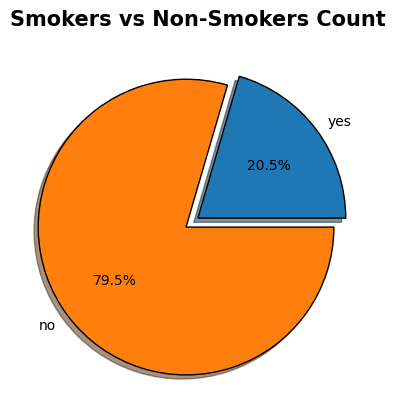

In [36]:
Explode = [0,0.1]
plt.title('Smokers vs Non-Smokers Count',fontdict={'fontweight':'bold','fontsize':'15'})
plt.pie(Smokers_Count['Count'].values,labels=Smokers_Count['smoker'].values,autopct='%1.1f%%',shadow=True,wedgeprops={'edgecolor':'black'},explode=Explode)
plt.show()

In [37]:
df.head()

,age,sex,bmi,children,smoker,region,medical_charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# No of Male and Females

In [38]:
Male_Female_Count = pd.read_sql_query('Select sex,Count(*) as Count from [dataset_] group by sex',con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_17200\2128893086.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Male_Female_Count = pd.read_sql_query('Select sex,Count(*) as Count from [dataset_] group by sex',con=connection)


In [39]:
Male_Female_Count

,sex,Count
0,male,676
1,female,662


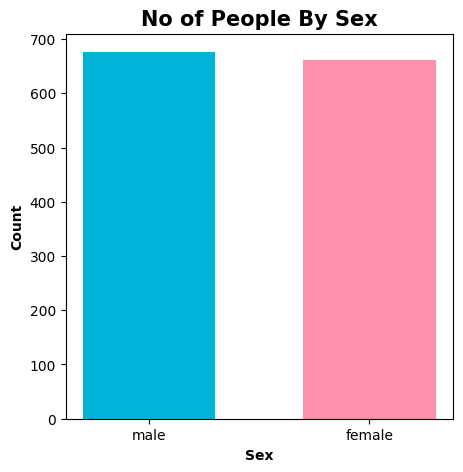

In [40]:
colors=['#00b4d8','#ff8fab']
plt.figure(figsize=(5,5))
plt.title('No of People By Sex',fontdict={'fontweight':'bold','fontsize':'15'})
plt.bar(Male_Female_Count['sex'],Male_Female_Count['Count'],width=0.6,color=colors)
plt.xlabel('Sex',fontdict={'fontweight':'bold'})
plt.ylabel('Count',fontdict={'fontweight':'bold'})
plt.show()

In [41]:
df.head()

,age,sex,bmi,children,smoker,region,medical_charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [42]:
print(df['age'].min())
print(df['age'].max())

18
64


# Creating Age Brackets Column

In [43]:
def age_Brackets(x):
    if 18 <= x <= 25:
        return '18-25'
    elif 26 <= x <= 30:
        return '26-30'
    elif 31 <= x <= 35:
        return '31-35'
    elif 36 <= x <= 40:
        return '36-40'
    elif 41 <= x <= 45:
        return '41-45'
    elif 46 <= x <= 50:
        return '46-50'
    elif x > 50:
        return '50 and Above'
    else:
        return 'Invalid'


In [44]:
df.rename(columns={'Age Brackets':'Age_Range'},inplace=True)

In [45]:
df['Age_Range'] = df['age'].apply(age_Brackets)

In [46]:
df.head()

,age,sex,bmi,children,smoker,region,medical_charges,Age_Range
0,19,female,27.900,0,yes,southwest,16884.92400,18-25
1,18,male,33.770,1,no,southeast,1725.55230,18-25
2,28,male,33.000,3,no,southeast,4449.46200,26-30
3,33,male,22.705,0,no,northwest,21984.47061,31-35
4,32,male,28.880,0,no,northwest,3866.85520,31-35


# No of People By Age Brackets

In [47]:
No_Of_People_By_Age_Range = df.groupby('Age_Range').agg({'sex':'count'}).sort_values(by='sex',ascending=False).reset_index()

In [48]:
No_Of_People_By_Age_Range

,Age_Range,sex
0,50 and Above,356
1,18-25,306
2,46-50,144
3,26-30,138
4,41-45,137
5,31-35,130
6,36-40,127


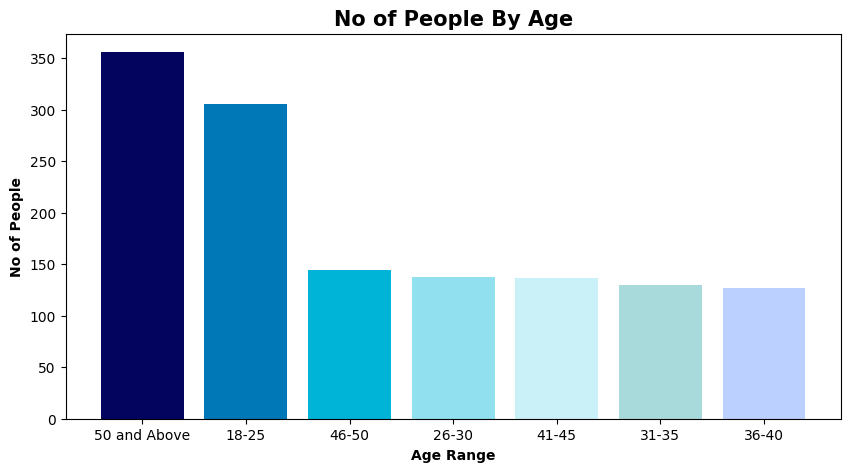

In [49]:
colors=['#03045e','#0077b6','#00b4d8','#90e0ef','#caf0f8','#a8dadc','#bbd0ff']
plt.figure(figsize=(10,5))
plt.title('No of People By Age',fontdict={'fontweight':'bold','fontsize':'15'})
plt.bar(No_Of_People_By_Age_Range['Age_Range'],No_Of_People_By_Age_Range['sex'],color=colors)
plt.xlabel('Age Range',fontdict={'fontweight':'bold'})
plt.ylabel('No of People',fontdict={'fontweight':'bold'})
plt.show()

In [50]:
df.head()

,age,sex,bmi,children,smoker,region,medical_charges,Age_Range
0,19,female,27.900,0,yes,southwest,16884.92400,18-25
1,18,male,33.770,1,no,southeast,1725.55230,18-25
2,28,male,33.000,3,no,southeast,4449.46200,26-30
3,33,male,22.705,0,no,northwest,21984.47061,31-35
4,32,male,28.880,0,no,northwest,3866.85520,31-35


# No of People By Region

In [51]:
People_BY_Region = pd.read_sql_query('Select region,Count(*) as Count from [dataset_] group by region',con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_17200\438558279.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  People_BY_Region = pd.read_sql_query('Select region,Count(*) as Count from [dataset_] group by region',con=connection)


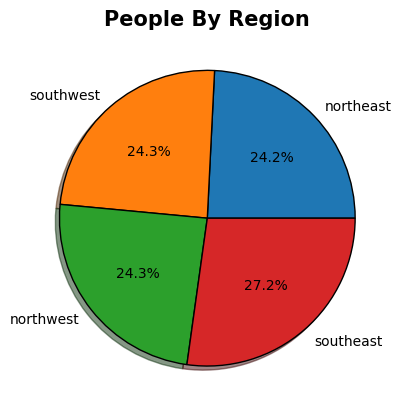

In [106]:
#Explode = [0,0.1]
plt.title('People By Region',fontdict={'fontweight':'bold','fontsize':'15'})
plt.pie(People_BY_Region['Count'].values,labels=People_BY_Region['region'].values,autopct='%1.1f%%',shadow=True,wedgeprops={'edgecolor':'black'})
plt.show()

In [53]:
df.head()

,age,sex,bmi,children,smoker,region,medical_charges,Age_Range
0,19,female,27.900,0,yes,southwest,16884.92400,18-25
1,18,male,33.770,1,no,southeast,1725.55230,18-25
2,28,male,33.000,3,no,southeast,4449.46200,26-30
3,33,male,22.705,0,no,northwest,21984.47061,31-35
4,32,male,28.880,0,no,northwest,3866.85520,31-35


# Children by Age_Range

In [54]:
AVG_Children_By_Age_Range = df.groupby('Age_Range').agg({'children':'mean'}).sort_values(by='children',ascending=False).reset_index()

In [55]:
AVG_Children_By_Age_Range

,Age_Range,children
0,36-40,1.606299
1,46-50,1.423611
2,31-35,1.407692
3,41-45,1.350365
4,26-30,1.224638
5,50 and Above,0.884831
6,18-25,0.666667


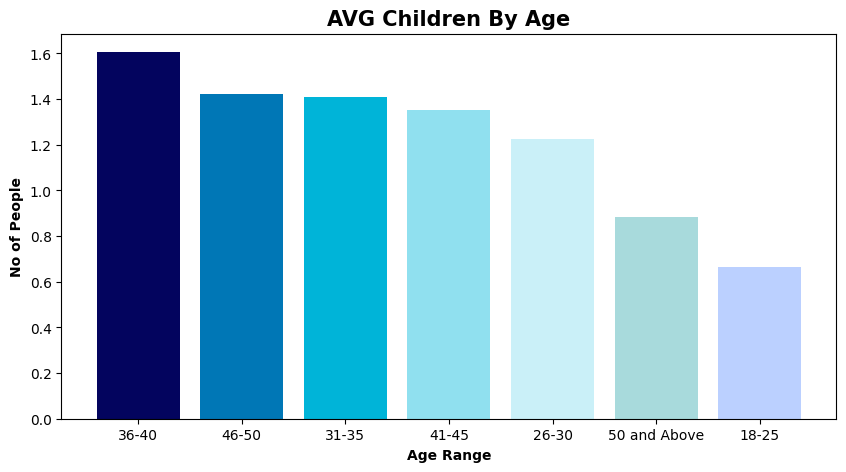

In [56]:
colors=['#03045e','#0077b6','#00b4d8','#90e0ef','#caf0f8','#a8dadc','#bbd0ff']
plt.figure(figsize=(10,5))
plt.title('AVG Children By Age',fontdict={'fontweight':'bold','fontsize':'15'})
plt.bar(AVG_Children_By_Age_Range['Age_Range'],AVG_Children_By_Age_Range['children'],color=colors)
plt.xlabel('Age Range',fontdict={'fontweight':'bold'})
plt.ylabel('No of People',fontdict={'fontweight':'bold'})
plt.show()

In [57]:
df.head()

,age,sex,bmi,children,smoker,region,medical_charges,Age_Range
0,19,female,27.900,0,yes,southwest,16884.92400,18-25
1,18,male,33.770,1,no,southeast,1725.55230,18-25
2,28,male,33.000,3,no,southeast,4449.46200,26-30
3,33,male,22.705,0,no,northwest,21984.47061,31-35
4,32,male,28.880,0,no,northwest,3866.85520,31-35


In [58]:
Smoker_Charges = pd.read_sql_query('Select smoker,AVG(medical_charges) as Charges from [dataset_] group by smoker',con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_17200\3270153998.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Smoker_Charges = pd.read_sql_query('Select smoker,AVG(medical_charges) as Charges from [dataset_] group by smoker',con=connection)


In [59]:
Smoker_Charges

,smoker,Charges
0,yes,32050.231832
1,no,8434.268298


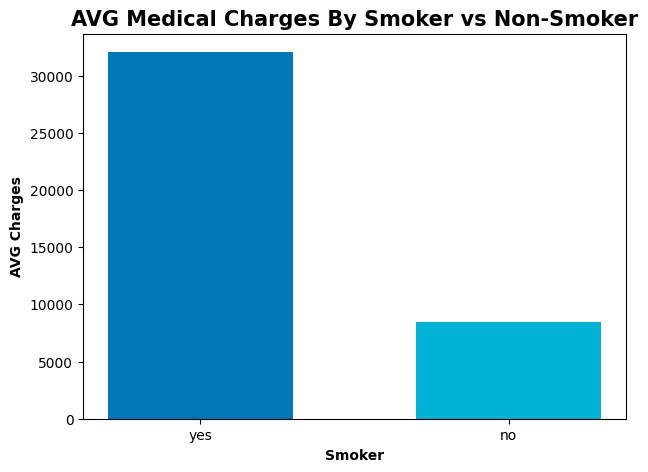

In [60]:
colors=['#0077b6','#00b4d8']
plt.figure(figsize=(7,5))
plt.title('AVG Medical Charges By Smoker vs Non-Smoker',fontdict={'fontweight':'bold','fontsize':'15'})
plt.bar(Smoker_Charges['smoker'],Smoker_Charges['Charges'],color=colors,width=0.6)
plt.xlabel('Smoker',fontdict={'fontweight':'bold'})
plt.ylabel('AVG Charges',fontdict={'fontweight':'bold'})
plt.show()

In [61]:
df.head()

,age,sex,bmi,children,smoker,region,medical_charges,Age_Range
0,19,female,27.900,0,yes,southwest,16884.92400,18-25
1,18,male,33.770,1,no,southeast,1725.55230,18-25
2,28,male,33.000,3,no,southeast,4449.46200,26-30
3,33,male,22.705,0,no,northwest,21984.47061,31-35
4,32,male,28.880,0,no,northwest,3866.85520,31-35


# Smokers By Age Range

In [62]:
Smoker_By_Age_Range = df.groupby(['Age_Range','smoker']).agg({'sex':'count'}).reset_index()

In [63]:
Smoker_By_Age_Range

,Age_Range,smoker,sex
0,18-25,no,241
1,18-25,yes,65
2,26-30,no,108
3,26-30,yes,30
4,31-35,no,104
5,31-35,yes,26
6,36-40,no,99
7,36-40,yes,28
8,41-45,no,104
9,41-45,yes,33


In [64]:
Smoker_By_Age_Range_Pivoted = Smoker_By_Age_Range.pivot(index='Age_Range',columns='smoker',values='sex').reset_index()

In [65]:
Smoker_By_Age_Range_Pivoted

smoker,Age_Range,no,yes
0,18-25,241,65
1,26-30,108,30
2,31-35,104,26
3,36-40,99,28
4,41-45,104,33
5,46-50,116,28
6,50 and Above,292,64


In [66]:
Age_Range = Smoker_By_Age_Range_Pivoted['Age_Range']
Smoker_yes = Smoker_By_Age_Range_Pivoted['yes']
Smoker_no = Smoker_By_Age_Range_Pivoted['no']

In [67]:
x_index = np.arange(len(Age_Range))
width = 0.3
# plt.figure(figsize=(10,7))
# plt.title('No of Smokers vs No Smokers By Age Group',fontdict={'fontweight':'bold','fontsize':'15'})
# plt.bar(x_index-1,Smoker_no,width=width,label='Not Smoker')
# plt.bar(x_index+1,Smoker_yes,width=width,label='Smoker')
# plt.xlabel('Smoker',fontdict={'fontweight':'bold'})
# plt.ylabel('AVG Charges',fontdict={'fontweight':'bold'})
# plt.legend()
# plt.xticks(ticks=x_index,labels=Age_Range)
# plt.show()

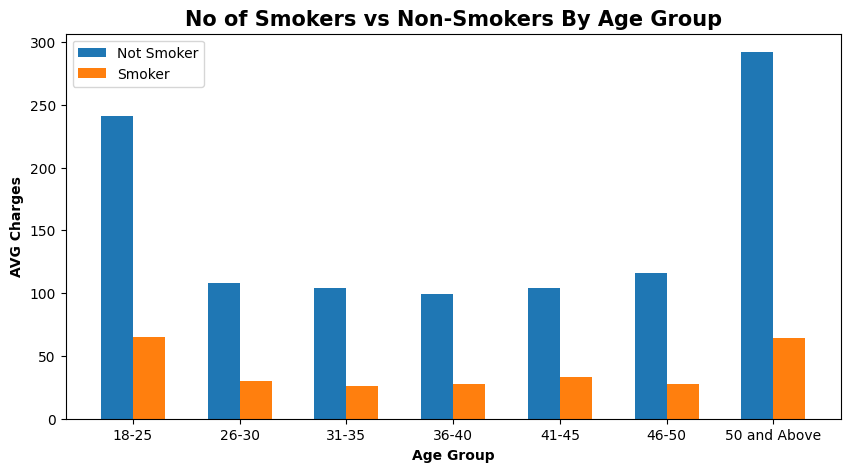

In [68]:
plt.figure(figsize=(10,5))
plt.title('No of Smokers vs Non-Smokers By Age Group', fontdict={'fontweight':'bold', 'fontsize':'15'})

# Adjust bar positions for better alignment
plt.bar(x_index - width/2, Smoker_no, width=width, label='Not Smoker')
plt.bar(x_index + width/2, Smoker_yes, width=width, label='Smoker')

plt.xlabel('Age Group', fontdict={'fontweight':'bold'})
plt.ylabel('AVG Charges', fontdict={'fontweight':'bold'})
plt.legend()

# Ensure that the number of ticks and labels match
plt.xticks(ticks=x_index, labels=Age_Range)

plt.show()

In [69]:
df.head()

,age,sex,bmi,children,smoker,region,medical_charges,Age_Range
0,19,female,27.900,0,yes,southwest,16884.92400,18-25
1,18,male,33.770,1,no,southeast,1725.55230,18-25
2,28,male,33.000,3,no,southeast,4449.46200,26-30
3,33,male,22.705,0,no,northwest,21984.47061,31-35
4,32,male,28.880,0,no,northwest,3866.85520,31-35


# Female vs Non_Female Smokers AVG Medical Charges

In [70]:
Smokers_Medical_Charges_By_Gender = pd.read_sql_query('Select sex,smoker,AVG(medical_charges) AS Medical_Charges from [dataset_] group by sex,smoker',con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_17200\2623058559.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Smokers_Medical_Charges_By_Gender = pd.read_sql_query('Select sex,smoker,AVG(medical_charges) AS Medical_Charges from [dataset_] group by sex,smoker',con=connection)


In [71]:
Smokers_Medical_Charges_By_Gender_Pivoted = Smokers_Medical_Charges_By_Gender.pivot(index='sex',columns='smoker',values='Medical_Charges').reset_index()

In [72]:
Smokers_Medical_Charges_By_Gender_Pivoted

smoker,sex,no,yes
0,female,8762.297300,30678.996276
1,male,8087.204731,33042.005975


In [73]:
Sex = Smokers_Medical_Charges_By_Gender_Pivoted['sex']
Yes = Smokers_Medical_Charges_By_Gender_Pivoted['yes']
No = Smokers_Medical_Charges_By_Gender_Pivoted['no']

([<matplotlib.axis.XTick at 0x150b3e4daf0>,
 [Text(0, 0, 'female'), Text(1, 0, 'male')])

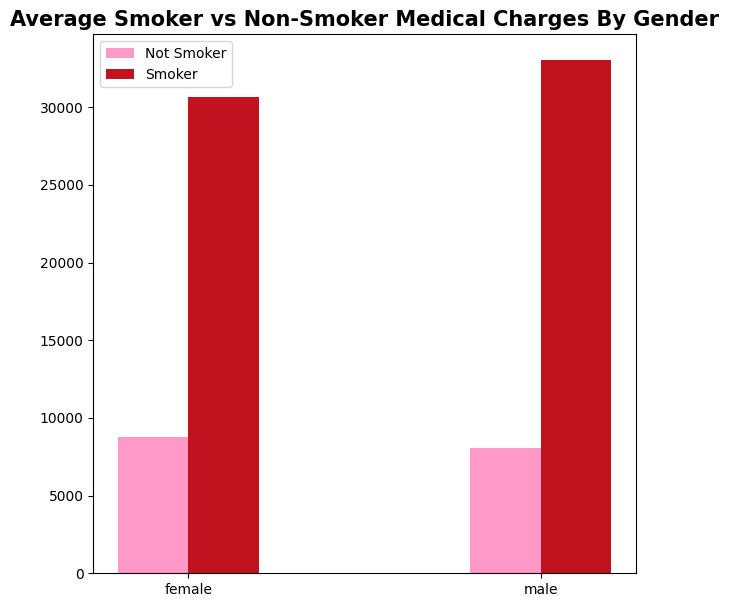

In [74]:
x_index = np.arange(len(Sex))
width = 0.2
plt.figure(figsize=(7,7))
plt.title('Average Smoker vs Non-Smoker Medical Charges By Gender',fontdict={'fontweight':'bold', 'fontsize':'15'})
plt.bar(x_index-width/2,No,width=width,label='Not Smoker',color='#ff99c8')
plt.bar(x_index+width/2,Yes,width=width,label='Smoker',color='#c1121f')
plt.legend()
plt.xticks(ticks=x_index,labels=Sex)

In [75]:
df.head()

,age,sex,bmi,children,smoker,region,medical_charges,Age_Range
0,19,female,27.900,0,yes,southwest,16884.92400,18-25
1,18,male,33.770,1,no,southeast,1725.55230,18-25
2,28,male,33.000,3,no,southeast,4449.46200,26-30
3,33,male,22.705,0,no,northwest,21984.47061,31-35
4,32,male,28.880,0,no,northwest,3866.85520,31-35


In [76]:
Average_BMI_Smoker_NON_Smoker = pd.read_sql_query('Select sex,smoker,AVG(bmi) AS AVG_BMI from [dataset_] group by sex,smoker',con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_17200\478685685.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Average_BMI_Smoker_NON_Smoker = pd.read_sql_query('Select sex,smoker,AVG(bmi) AS AVG_BMI from [dataset_] group by sex,smoker',con=connection)


In [77]:
Average_BMI_Smoker_NON_Smoker

,sex,smoker,AVG_BMI
0,female,yes,29.608261
1,female,no,30.539525
2,male,no,30.770580
3,male,yes,31.504182


In [78]:
Average_BMI_Smoker_NON_Smoker_Pivoted = Average_BMI_Smoker_NON_Smoker.pivot(index='sex',columns='smoker',values='AVG_BMI').reset_index()

In [79]:
Average_BMI_Smoker_NON_Smoker_Pivoted

smoker,sex,no,yes
0,female,30.539525,29.608261
1,male,30.770580,31.504182


In [80]:
SEX  = Average_BMI_Smoker_NON_Smoker_Pivoted['sex']
Yes  = Average_BMI_Smoker_NON_Smoker_Pivoted['yes']
No  = Average_BMI_Smoker_NON_Smoker_Pivoted['no']

([<matplotlib.axis.XTick at 0x150b5333b00>,
 [Text(0, 0, 'female'), Text(1, 0, 'male')])

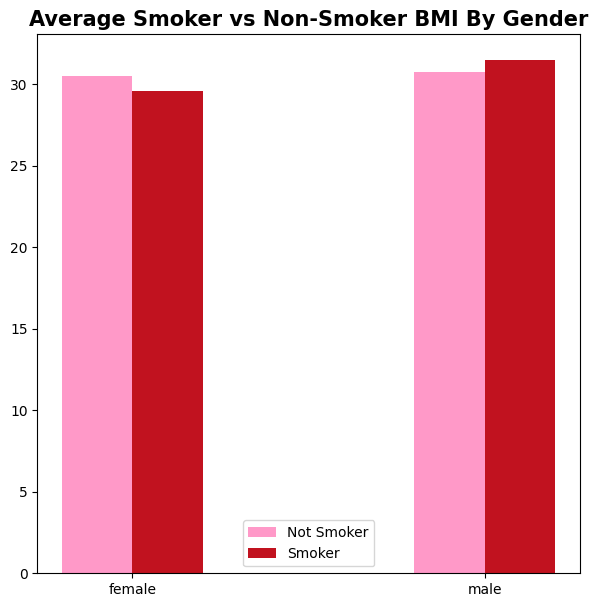

In [81]:
x_index = np.arange(len(Sex))
width = 0.2
plt.figure(figsize=(7,7))
plt.title('Average Smoker vs Non-Smoker BMI By Gender',fontdict={'fontweight':'bold', 'fontsize':'15'})
plt.bar(x_index-width/2,No,width=width,label='Not Smoker',color='#ff99c8')
plt.bar(x_index+width/2,Yes,width=width,label='Smoker',color='#c1121f')
plt.legend()
plt.xticks(ticks=x_index,labels=Sex)

In [82]:
df.head()

,age,sex,bmi,children,smoker,region,medical_charges,Age_Range
0,19,female,27.900,0,yes,southwest,16884.92400,18-25
1,18,male,33.770,1,no,southeast,1725.55230,18-25
2,28,male,33.000,3,no,southeast,4449.46200,26-30
3,33,male,22.705,0,no,northwest,21984.47061,31-35
4,32,male,28.880,0,no,northwest,3866.85520,31-35


# Statistical Test

## Correlation Test Age and Medical Charges Person or Spearman Test

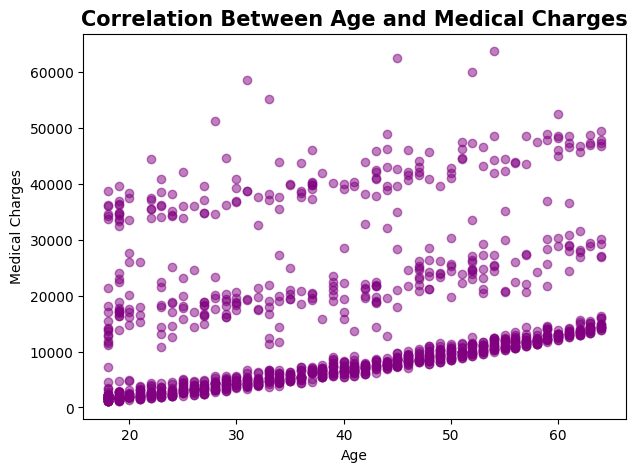

In [83]:
plt.figure(figsize=(7,5))
plt.title('Correlation Between Age and Medical Charges',fontdict={'fontweight':'bold', 'fontsize':'15'})
plt.xlabel('Age')
plt.ylabel('Medical Charges')
plt.scatter(df['age'],df['medical_charges'],color='purple',alpha=0.5)
plt.show()

In [84]:
corr,p_value = stats.pearsonr(df['age'],df['medical_charges'])
print(f'Pearson correlation: {corr}, p-value: {p_value}')

if p_value < 0.05:
    print('There is a significant correlation between Age and Medical Charges.')
else:
    print('There is no significant correlation between Age and Medical Charges.')

Pearson correlation: 0.2990081933306476, p-value: 4.886693331718663e-29
There is a significant correlation between Age and Medical Charges.


In [85]:
BMI = df['bmi']

In [86]:
Medical_Charges = df['medical_charges']

In [87]:
corr,p_value = stats.pearsonr(BMI,Medical_Charges)
print(f'Pearson correlation: {corr}, p-value: {p_value}')

if p_value < 0.05:
    print('There is a significant correlation between BMI and Medical Charges.')
else:
    print('There is no significant correlation between BMI and Medical Charges.')

Pearson correlation: 0.1983409688336289, p-value: 2.459085535116776e-13
There is a significant correlation between BMI and Medical Charges.


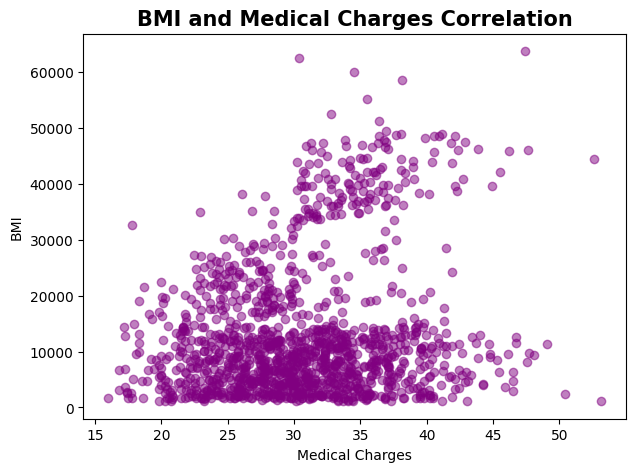

In [88]:
plt.figure(figsize=(7,5))
plt.title('BMI and Medical Charges Correlation',fontdict={'fontweight':'bold', 'fontsize':'15'})
plt.xlabel('Medical Charges')
plt.ylabel('BMI')
plt.scatter(df['bmi'],df['medical_charges'],color='purple',alpha=0.5)
plt.show()

# T-Test Compare Means of Medical Charges of Smokers and Non-Smokers

In [89]:
df.head()

,age,sex,bmi,children,smoker,region,medical_charges,Age_Range
0,19,female,27.900,0,yes,southwest,16884.92400,18-25
1,18,male,33.770,1,no,southeast,1725.55230,18-25
2,28,male,33.000,3,no,southeast,4449.46200,26-30
3,33,male,22.705,0,no,northwest,21984.47061,31-35
4,32,male,28.880,0,no,northwest,3866.85520,31-35


In [90]:
Smoker = df[df['smoker']=='yes']

In [91]:
Smoker_Medical_Charges = Smoker['medical_charges']

In [92]:
Smoker_Medical_Charges.mean()

np.float64(32050.23183153284)

In [93]:
Non_Smoker = df[df['smoker']=='no']

In [94]:
Non_Smoker

,age,sex,bmi,children,smoker,region,medical_charges,Age_Range
1,18,male,33.770,1,no,southeast,1725.55230,18-25
2,28,male,33.000,3,no,southeast,4449.46200,26-30
3,33,male,22.705,0,no,northwest,21984.47061,31-35
4,32,male,28.880,0,no,northwest,3866.85520,31-35
5,31,female,25.740,0,no,southeast,3756.62160,31-35
...,...,...,...,...,...,...,...,...
1332,52,female,44.700,3,no,southwest,11411.68500,50 and Above
1333,50,male,30.970,3,no,northwest,10600.54830,46-50
1334,18,female,31.920,0,no,northeast,2205.98080,18-25
1335,18,female,36.850,0,no,southeast,1629.83350,18-25


In [95]:
Non_smoker_MedicalCharges = Non_Smoker['medical_charges']

In [96]:
Non_smoker_MedicalCharges.mean()

np.float64(8434.268297856204)

In [97]:
t_test,p_value = stats.ttest_ind(Smoker_Medical_Charges,Non_smoker_MedicalCharges,equal_var=False)
print(p_value)
if(p_value<0.05):
    print('There is a Difference Between Mean of Medical Charges of Smoker and Non-Smoker')
else:
    print('There is no Difference Between Mean of Medical Charges of Smoker and Non-Smoker')    

5.88946444671698e-103
There is a Difference Between Mean of Medical Charges of Smoker and Non-Smoker


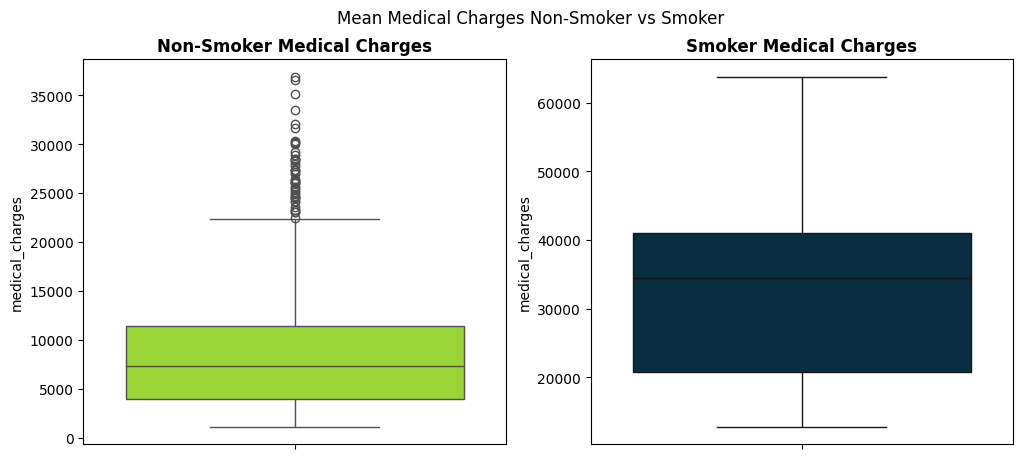

In [98]:
# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot the boxplot for non-smokers in the first subplot
sns.boxplot(y=Non_smoker_MedicalCharges, ax=ax[0],color='#9ef01a')
ax[0].set_title('Non-Smoker Medical Charges',fontdict={'fontweight':'bold'})

# Plot the boxplot for smokers in the second subplot
sns.boxplot(y=Smoker_Medical_Charges, ax=ax[1],color='#003049')
ax[1].set_title('Smoker Medical Charges',fontdict={'fontweight':'bold'})

# Set the overall title for the figure
plt.suptitle('Mean Medical Charges Non-Smoker vs Smoker ',fontdict={'fontweight':'bold'})

# Display the plots
plt.show()

# One Way Annova To Compare Means Between three or more Groups

In [99]:
df.head()

,age,sex,bmi,children,smoker,region,medical_charges,Age_Range
0,19,female,27.900,0,yes,southwest,16884.92400,18-25
1,18,male,33.770,1,no,southeast,1725.55230,18-25
2,28,male,33.000,3,no,southeast,4449.46200,26-30
3,33,male,22.705,0,no,northwest,21984.47061,31-35
4,32,male,28.880,0,no,northwest,3866.85520,31-35


In [100]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [101]:
f_stat, p_value = stats.f_oneway(df[df['region'] == 'southeast']['medical_charges'],
                                 df[df['region'] == 'southwest']['medical_charges'],
                                 df[df['region'] == 'northwest']['medical_charges'],
                                 df[df['region'] == 'northeast']['medical_charges'])
print(f'ANOVA F-statistic: {f_stat}, p-value: {p_value}')

if p_value < 0.05:
    print('There is a significant difference in medical charges across regions.')
else:
    print('There is no significant difference in medical charges across regions.')


ANOVA F-statistic: 2.96962669358912, p-value: 0.0308933560705201
There is a significant difference in medical charges across regions.


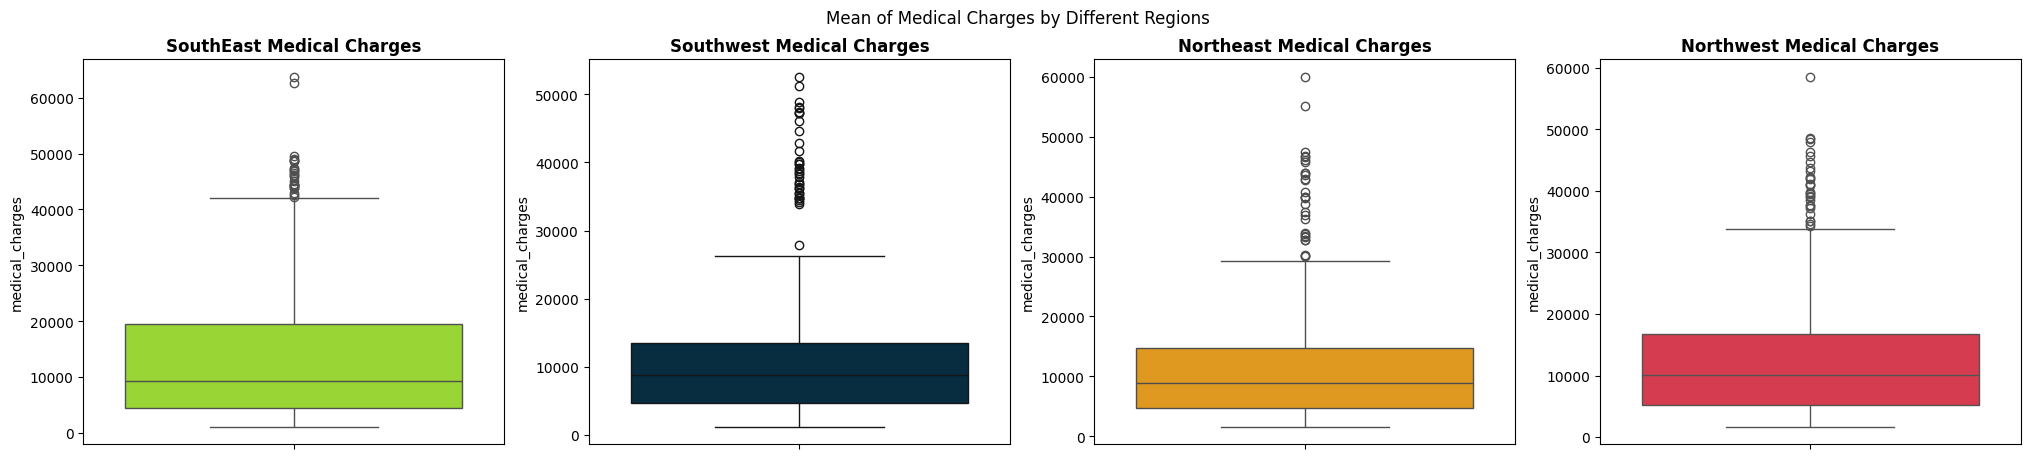

In [102]:
# Create a figure with two subplots
fig, ax = plt.subplots(1, 4, figsize=(25, 5))

# Plot the boxplot for non-smokers in the first subplot
sns.boxplot(y=df[df['region'] == 'southeast']['medical_charges'], ax=ax[0],color='#9ef01a')
ax[0].set_title('SouthEast Medical Charges',fontdict={'fontweight':'bold'})

# Plot the boxplot for smokers in the second subplot
sns.boxplot(y=df[df['region'] == 'southwest']['medical_charges'], ax=ax[1],color='#003049')
ax[1].set_title('Southwest Medical Charges',fontdict={'fontweight':'bold'})

sns.boxplot(y=df[df['region'] == 'northwest']['medical_charges'], ax=ax[2],color='#ffa200')
ax[2].set_title('Northeast Medical Charges',fontdict={'fontweight':'bold'})

sns.boxplot(y= df[df['region'] == 'northeast']['medical_charges'], ax=ax[3],color='#ef233c')
ax[3].set_title('Northwest Medical Charges',fontdict={'fontweight':'bold'})
# Set the overall title for the figure
plt.suptitle('Mean of Medical Charges by Different Regions ',fontdict={'fontweight':'bold'})

# Display the plots
plt.show()

# Chi-Square Test  used to Check Association B/W two Categories

In [103]:
# Create a contingency table
contingency_table = pd.crosstab(df['smoker'], df['region'])

# Perform Chi-Square test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f'Chi-square test statistic: {chi2}, p-value: {p_value}')

if p_value < 0.05:
    print('There is a significant association between smoker status and region.')
else:
    print('There is no significant association between smoker status and region.')

Chi-square test statistic: 7.34347776140707, p-value: 0.06171954839170547
There is no significant association between smoker status and region.


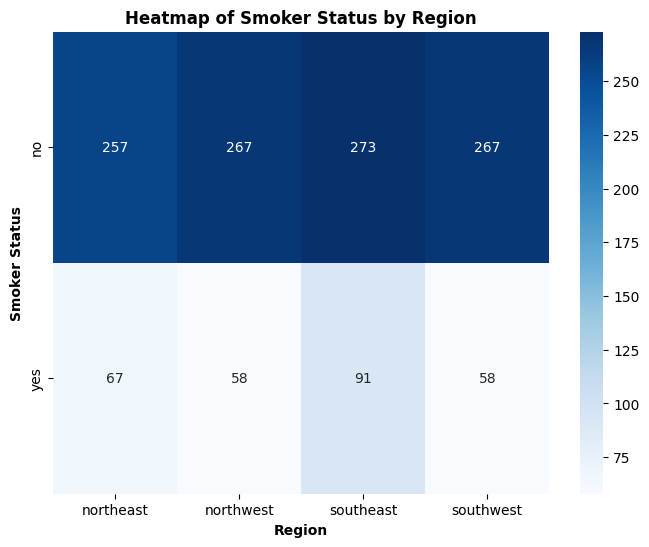

In [104]:
# Plot a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Blues')
plt.title('Heatmap of Smoker Status by Region', fontweight='bold')
plt.xlabel('Region', fontweight='bold')
plt.ylabel('Smoker Status', fontweight='bold')
plt.show()

In [105]:
df.to_csv(r'E:\Data Analyst Roadmap\Google Data Analytics Certificate Course\Different Analysis\Medical Cost Dataset\Analysis SQL Python\Medical_Cost_Cleaned.csv',index=False)